# Day 4 — Activations, Gradients, BatchNorm (makemore Part 3, 1h55m)
Lecture names used (n_embd, n_hidden, block_size, vocab_size). Init fixes + BatchNorm + Linear/BatchNorm1d/Tanh classes = my exercises. Starting network is deliberately pre-fix.

In [43]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
# BOILERPLATE: data + maps + split
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

block_size = 3

def build_dataset(word_list):
    X, Y = [], []
    for w in word_list:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [45]:
# starting network — NAIVE init (the video's fixes are my exercise)
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [46]:
# BOILERPLATE: optimization loop (use small max_steps during the surgery phase)
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3221
  10000/ 200000: 2.1900
  20000/ 200000: 2.4196
  30000/ 200000: 2.6067
  40000/ 200000: 2.0601
  50000/ 200000: 2.4988
  60000/ 200000: 2.3902
  70000/ 200000: 2.1344
  80000/ 200000: 2.3369
  90000/ 200000: 2.1299
 100000/ 200000: 1.8329
 110000/ 200000: 2.2053
 120000/ 200000: 1.8540
 130000/ 200000: 2.4566
 140000/ 200000: 2.1879
 150000/ 200000: 2.1118
 160000/ 200000: 1.8956
 170000/ 200000: 1.8644
 180000/ 200000: 2.0326
 190000/ 200000: 1.8417


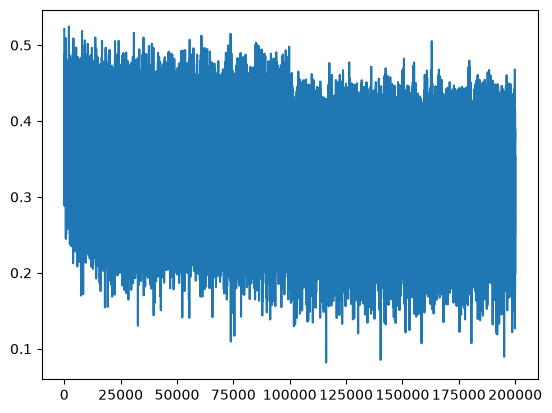

In [47]:
plt.plot(lossi)

In [48]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')

train 2.0695888996124268
dev 2.131074905395508


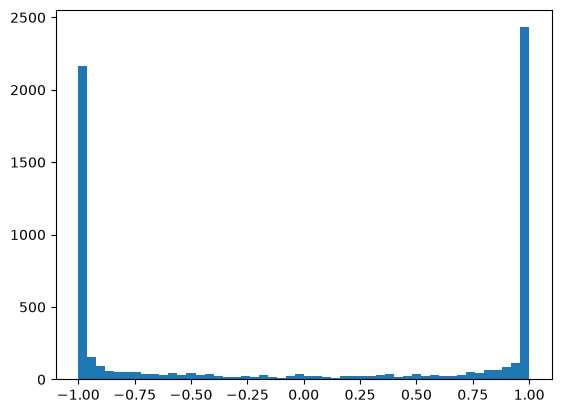

In [49]:
# BOILERPLATE (segment viz, from the lecture): distribution of h — where do activations live?
plt.hist(h.view(-1).tolist(), 50);

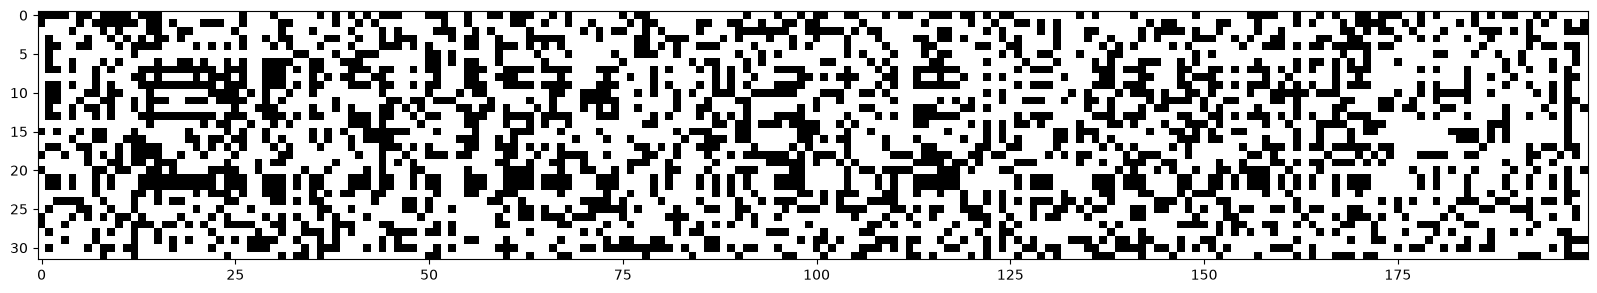

In [50]:
# BOILERPLATE (segment viz, from the lecture): saturation map — white = |h| > 0.99 (dead-ish)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

## observations — naive init, 200k run

- first loss 27.88 (same as karpathy), should be ~3.29. confidently wrong at init, same as my 21.9 thing before
- loss curve = hockey stick, early steps wasted just fixing the init
- still ended at train 2.1268 / dev 2.1698 tho. bad init didnt kill it, just wasted time (shallow net, deep would die)
- h histogram = two towers at ±1, saturated
- saturation map has a lot of white, those units have grad ~0

-
 
d
e
r
i
v
e
d
 
t
h
e
 
i
d
e
a
l
 
i
n
i
t
 
l
o
s
s
 
w
i
t
h
 
a
 
t
o
y
:
 
c
r
o
s
s
_
e
n
t
r
o
p
y
(
z
e
r
o
s
(
2
7
)
,
 
y
)
 
=
 
-
l
o
g
(
1
/
2
7
)
 
=
 
*
*
3
.
2
9
5
8
*
*
.
 
s
o
 
l
o
g
i
t
s
 
s
h
o
u
l
d
 
s
t
a
r
t
 
~
0
 
-
>
 
o
u
t
p
u
t
 
l
a
y
e
r
 
w
e
i
g
h
t
s
 
(
W
2
,
 
b
2
)
 
n
e
a
r
 
0
 
a
t
 
i
n
i
t

In [51]:
a = torch.zeros(27).float()
y = torch.tensor(1)
loss = F.cross_entropy(a, y)
loss

tensor(3.2958)